# Binary spatial colocalization

In all previous notebooks, the input map `Y` was a continuous brain map — a z-score, a Cohen's d, a correlation coefficient. But sometimes `Y` is **binary**: a network mask, an ROI, a lesion map, a thresholded cluster map.

For binary data, spatial colocalization reduces to **point-biserial correlation**, which is mathematically equivalent to Pearson correlation. Spearman rank correlation degrades with heavily tied data (most parcels = 0), making Pearson the correct choice.

Setting `binary_y=True` in NiSpace:
- Prevents z-scoring of `Y` (which would distort binary values)
- Sets `colocalization_method="pearson"` when no method is specified
- Issues a warning if a ranked method is requested

In this notebook we use the **Yeo 7 functional networks** (Yeo et al. 2011) as binary `Y` maps and ask which cortical features (cell types, gradients, myelination) are enriched in each network.

In [35]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn.datasets import fetch_atlas_yeo_2011
from nispace.workflows import colocalization
from nispace.plotting import brainplot

## Loading the Yeo 7 networks

The Yeo 2011 atlas defines 7 large-scale functional brain networks from resting-state fMRI. We use the `thick_7` variant (7 networks, thickened boundaries for better MNI-space coverage). Each voxel is labelled 0 (background) or 1–7 (network ID). We extract 7 binary NIfTI images, one per network.

In [45]:
yeo = fetch_atlas_yeo_2011(n_networks=7, thickness="thick")
thick7 = nib.load(yeo.maps)
data   = thick7.get_fdata().squeeze()

# Canonical Yeo 7 network names (Yeo et al. 2011)
yeo_names = {
    1: "Visual",
    2: "SomMot",
    3: "DorsAttn",
    4: "SalVentAttn",
    5: "Limbic",
    6: "Control",
    7: "Default",
}

# Extract one binary NIfTI per network
yeo_imgs   = [nib.Nifti1Image((data == i).astype(np.float32), thick7.affine)
              for i in yeo_names]
yeo_labels = list(yeo_names.values())

# save in dict for use with NiSpace
yeo_dict = dict(zip(yeo_labels, yeo_imgs))

print("Networks:", yeo_labels)
for name, img in yeo_dict:
    n_voxels = int(img.get_fdata().sum())
    print(f"  {name}: {n_voxels} voxels")

[fetch_atlas_yeo_2011] Dataset found in /Users/llotter/nilearn_data/yeo_2011
Networks: ['Visual', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Control', 'Default']


ValueError: too many values to unpack (expected 2)

WARNING | 12/07/26 01:22:41 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


(<Figure size 1440x840 with 43 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >])

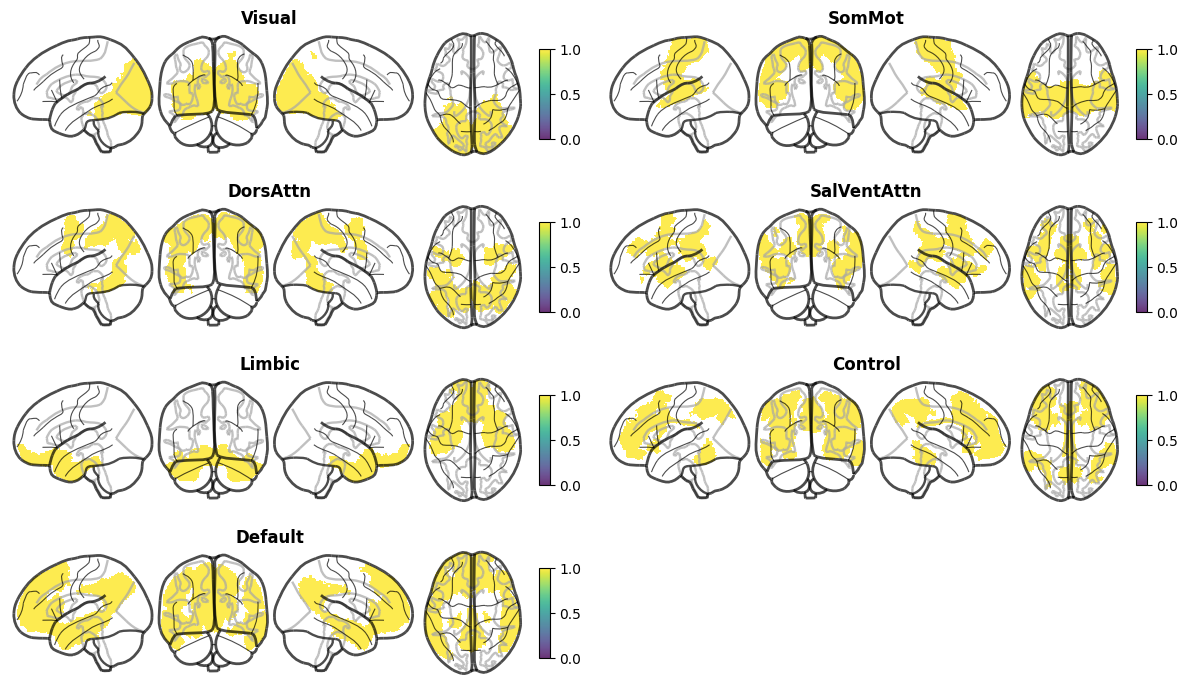

In [23]:
# Visualize the networks as a sanity check
brainplot(yeo_imgs, title=list(yeo_names.values()), ncols=2)

## Analysis A: functional network overlap (positive control)

As a positive control, we test colocalization with the `rsn17` reference dataset — 17 resting-state networks that partially overlap with the Yeo 7 parcellation. We expect high within-network overlap (same network, different parcellation) and low across-network overlap.

This is a **positive control**: if we don't recover the block structure (Visual ↔ Visual, Default ↔ Default, etc.), something is wrong with the pipeline or the data.

In [47]:
nsp_a = colocalization(
    x="rsn17",
    y=yeo_dict,
    parcellation="Yan200",
    binary_y=True,          # Y is binary: prevents z-scoring, auto-selects pearson
    n_perm=1000,
    seed=42,
    n_proc=-1,
    plot=False,
    return_nispace_only=True
)

INFO | 12/07/26 01:31:55 | nispace.workflows: Loading integrated rsn17 dataset as X data.
INFO | 12/07/26 01:31:55 | nispace.datasets: Loading rsn17 maps.
INFO | 12/07/26 01:31:55 | nispace.datasets: Loading data parcellated with 'Yan200'
The NiSpace "RSN17" dataset contains resting-state network probability maps describing the 17 "Kong"
networks. The maps were derived from individual-level cortical parcellations of 1029 HCP subjects
into 17 functional networks, generated as described in Kong et al., 2021 and made available at
https://github.com/ThomasYeoLab/Kong2022_ArealMSHBM. The maps are only available in fsLR and
fsaverage spaces. Note that the networks follow the Kong et al. naming convention, which differs
from the 17 "Yeo networks". Please cite the original publication when using these maps.
  - Kong et al., 2021  https://doi.org/10.1093/cercor/bhab101
To ensure reproducibility, note the NiSpace version: 0.0.1b5.dev68+g20be93445.d20260520 (commit: g20be93445).

INFO | 12/07/26 

Colocalizing (pearson, -1 proc): 100%|██████████| 7/7 [00:00<00:00, 9859.01it/s]


INFO | 12/07/26 01:32:17 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.
INFO | 12/07/26 01:32:17 | nispace.core.permute: Generating null maps (n = 1000, null_method = 'cornblath').
INFO | 12/07/26 01:32:17 | nispace.nulls: Null map generation: Assuming n = 17 data vector(s) for n = 200 parcels.
INFO | 12/07/26 01:32:17 | nispace.nulls: Using provided precomputed Cornblath transition matrix.


Cornblath null maps: 100%|██████████| 17/17 [00:01<00:00, 16.00it/s]

INFO | 12/07/26 01:32:18 | nispace.nulls: Null data generation finished.
INFO | 12/07/26 01:32:18 | nispace.core.permute: Z-standardizing null maps.



Null colocalizations (pearson, -1 proc): 100%|██████████| 1000/1000 [00:00<00:00, 8104.73it/s]


INFO | 12/07/26 01:32:19 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


<Axes: xlabel='map'>

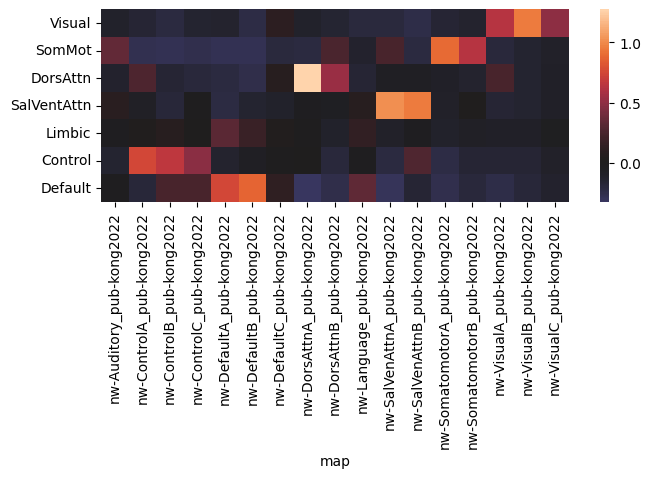

In [49]:
# the straight-forward way to visualize this is a heatmap
fig, ax = plt.subplots(1, figsize=(8,2.5))
sns.heatmap(
    nsp_a.get_colocalizations(),
    center=0,
    square=True
)

## Analysis B: cortical organization features

Now we ask a more substantive question: which structural and organizational features of the cortex are enriched in each Yeo 7 network?

We use the `cortexfeatures` reference dataset with the `CortexOrganisation` collection, which includes 11 maps spanning:
- **Morphology**: cortical thickness, T1w/T2w myelination proxy
- **Gradients**: sensorimotor-to-association (SA) axis, FC gradients 1–3 (Margulies et al. 2016)
- **Developmental/evolutionary expansion** (Hill et al. 2010; Xu et al. 2020)
- **Species homology**, gene expression PC1

Expected patterns:
- **Myelination** (`feature-t1t2`): highest in SomMot (heavily myelinated sensorimotor cortex), lowest in Default (lightly myelinated association cortex)
- **FC gradient 1** (`feature-fcgradient1`): captures the unimodal-to-transmodal axis — aligns strongly with the Default network at one end and SomMot/Visual at the other

In [53]:
nsp_b = colocalization(
    x="cortexfeatures",
    x_collection="CortexOrganisation",  # 11 maps: thickness, myelination, SA axis, FC gradients, expansion, homology
    y=yeo_dict,
    parcellation="Yan200",
    binary_y=True,
    n_perm=1000,
    seed=42,
    n_proc=-1,
    plot=False,
    return_nispace_only=True
)

INFO | 12/07/26 01:33:22 | nispace.workflows: Loading integrated cortexfeatures dataset as X data.
INFO | 12/07/26 01:33:22 | nispace.datasets: Loading cortexfeatures maps.
INFO | 12/07/26 01:33:22 | nispace.datasets: Loading integrated collection 'CortexOrganisation' for dataset 'cortexfeatures'.
INFO | 12/07/26 01:33:22 | nispace.datasets: Filtering maps by collection.
INFO | 12/07/26 01:33:22 | nispace.datasets: Loading data parcellated with 'Yan200'
The NiSpace "CortexFeatures" dataset consists of different features of cortical topology available
via neuromaps. Many of these maps were used in Shafiei et al., 2023. The maps are fetched directly
from neuromaps (space="fsLROriginal" or "fsaverageOriginal") or downloaded from the NiSpace-data
GitHub repo (space="fsLR" or "fsaverage"; recommended). Please cite neuromaps (https://neuromaps-
main.readthedocs.io/) and the original publication for each map when used.
  - Markello et al., 2022  https://doi.org/10.1038/s41592-022-01625-w
  - 

Colocalizing (pearson, -1 proc): 100%|██████████| 7/7 [00:00<00:00, 8226.43it/s]

INFO | 12/07/26 01:33:34 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.
INFO | 12/07/26 01:33:34 | nispace.core.permute: Generating null maps (n = 1000, null_method = 'cornblath').
INFO | 12/07/26 01:33:34 | nispace.nulls: Null map generation: Assuming n = 8 data vector(s) for n = 200 parcels.
INFO | 12/07/26 01:33:34 | nispace.nulls: Using provided precomputed Cornblath transition matrix.



Cornblath null maps: 100%|██████████| 8/8 [00:00<00:00, 15.72it/s]

INFO | 12/07/26 01:33:35 | nispace.nulls: Null data generation finished.
INFO | 12/07/26 01:33:35 | nispace.core.permute: Z-standardizing null maps.



Null colocalizations (pearson, -1 proc): 100%|██████████| 1000/1000 [00:00<00:00, 8483.13it/s]


INFO | 12/07/26 01:33:35 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


Text(0.5, 1.0, '$☆: p < 0.05,\\ ★: p_{Meff} < 0.05$')

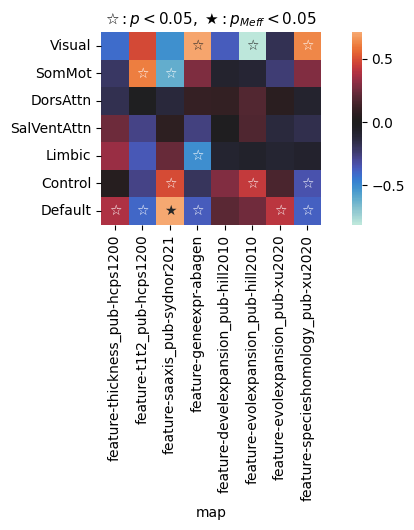

In [69]:
# this time with significance annotation
data = nsp_b.get_colocalizations()
p = nsp_b.get_p_values()
pc = nsp_b.get_corrected_p_values()
annot = ((p < 0.05).astype(int) + (pc < 0.05).astype(int)).replace({0: "", 1: "☆", 2: "★"})

fig, ax = plt.subplots(1, figsize=(8,2.5))
sns.heatmap(
    data,
    annot=annot,
    fmt="s",
    center=0,
    square=True
)
ax.set_title("$☆: p < 0.05,\ ★: p_{Meff} < 0.05$", size=11)

## Summary

- `binary_y=True` in `NiSpace()` or in any workflow function switches to binary-Y mode: no z-scoring, Pearson auto-selected.
- Binary colocalization = point-biserial correlation; Spearman degrades with many tied zeros.
- `colocalization(x=..., y=binary_maps, binary_y=True)` is the one-liner workflow.
- The Yeo 7 example shows how to extract binary masks from an atlas NIfTI and test them against any NiSpace reference dataset.

For the NiMARE case (binary ALE cluster maps as Y, with a coordinate-sampling null), see the [NiMARE integration notebook](intro12_nimare_integration.ipynb).